In [1]:
# import os
# import json
# from PIL import Image
# from scipy.ndimage import gaussian_filter

# import cv2
# import numpy as np
# import torch

# from vision_process import process_vision_info
# from orthography import Orthophoto
# from dataset.vis_data import visualize_waypoints
# from pathlib import Path

# video_frame_num = 5
# target_interval = 30
# data_list_json_paths = ["../data/train_data_sample.json"]
# visualize = False
# sigma = 20
# visual_prompt = True

# data_list = []
# for file in data_list_json_paths:
#     with open(file, "r") as f:
#         datum = json.load(f)
#     data_list += datum

# data = data_list

# ortho_processor = Orthophoto(granularity=0.3)

# idx = 5

# def preprocess(image, pad_color=(0, 0, 0)):
#     img_size = 784
#     h, w = image.shape[:2]
#     scale = img_size * 1.0 / max(h, w)
#     new_h, new_w = h * scale, w * scale
#     new_w = int(new_w + 0.5)
#     new_h = int(new_h + 0.5)
#     resized_image = cv2.resize(image, (new_w, new_h), interpolation=cv2.INTER_NEAREST)
#     resized_hw = (new_h, new_w)

#     pad_h = img_size - new_h
#     pad_w = img_size - new_w
#     padded_image = cv2.copyMakeBorder(resized_image, 0, pad_h, 0, pad_w,
#                                     cv2.BORDER_CONSTANT, value=pad_color)
#     return padded_image, resized_hw

# def generate_prob_message_v2(pil_image, description):
#     visual_prompt = True
#     if isinstance(pil_image, np.ndarray):
#         pil_image = Image.fromarray(pil_image)
#     if isinstance(description, list):
#         description = description[0]
#     text_parts = description.split("The description of the target and its surrounding is shown below.")
#     direction = text_parts[0].strip().split("Compass north corresponds to the top of the bird's-eye-view image.")[-1]
#     direction = direction.strip()
#     object_description = text_parts[-1].strip()

#     prob_message = [{
#         'role':'user',
#         'content':[
#             {'type':'image', 'image':pil_image},
#             {'type':'text', 'text': "Task: Predict the probability distribution of the drone's future flight locations to search for the target."
#             "Input Image: The image is an orthophoto map generated from the drone's past flight trajectory."},
#             {'type':'text', 'text': "The green dots indicate past drone positions." if visual_prompt else " "},
#             {'type':'text', 'text': "The top of the image corresponds to the north in the world coordinate system.\n" 
#             f"Target Information: {direction}"
#             f"The description of the target and its surrounding is shown below: {object_description}\n"
#             "Objective: "
#             "Analyze the provided orthophoto map and target information."
#             "Predict the next flight location for the drone that maximize the probability of finding the target."
#             "Output a probability map, indicating the likelihood of different regions in the orthophoto map being the optimal next flight destinations."
#             }
#         ]
#     },
#     {
#         'role':'assistant',
#         'content':[
#             {'type':'image', 'image':pil_image}
#         ]
#     }
#     ]
#     return prob_message
    
# def gaussian(target, img_size):
#     sigma = 20
#     h, w = img_size
#     prob_map = np.zeros((h, w), dtype=np.float32)
#     i, j = target
#     i, j = min(round(i),h-1), min(round(j),w-1)
#     i_1 = min(h-1, i+1)
#     j_1 = min(w-1, j+1)
#     i_2 = max(0, i-1)
#     j_2 = max(0, j-1)
#     prob_map[i, j] = 1
#     prob_map[i, j_1] = 1
#     prob_map[i, j_2] = 1
#     prob_map[i_1, j] = 1
#     prob_map[i_2, j] = 1

#     sigma = max(h,w) // 25 if sigma is None else sigma
#     prob_map = gaussian_filter(prob_map, sigma=sigma)
#     return prob_map

# def get_prob_map(ortho, coor_map, end, ortho_depth=None, delta_height=None):
#     h, w = ortho.shape[:2]
#     if ortho_depth is not None:
#         depth_mask = (ortho_depth > delta_height).reshape(h,w)
#     i, j = ortho_processor.world_to_pixel(end, coor_map=coor_map)
#     i, j = min(max(round(i), 0), h-1), min(max(round(j), 0), w-1)
#     prob_map_0 = np.zeros((h, w))
#     prob_map_0[i, j] = 1

#     yy, xx = np.ogrid[:h, :w]
#     distances = np.sqrt((yy - i)**2 + (xx - j)**2)
#     max_dist = np.sqrt(2*(h-1)**2)
#     prob_map_0 = 1 - distances / max_dist
#     prob_map_0[~depth_mask] = 0

#     new_i, new_j = np.unravel_index(np.argmax(prob_map_0), (h, w))
#     prob_map = gaussian((new_i, new_j), (h, w))
#     # prob_map[~depth_mask] = 0
#     prob_map = prob_map / (np.max(prob_map) + 1e-6)

#     return prob_map, depth_mask


# data_info = data[idx]
# traj_dir = data_info["traj_folder_path"]
# traj_dir = os.path.join("..", traj_dir)
# depth_dir = os.path.join(traj_dir, "bevcamera_depth")
# image_dir = os.path.join(traj_dir, "bevcamera")
# log_dir = os.path.join(traj_dir, "log")
# image_path = data_info["image_path"]

# high_uav_pos_now = data_info["high_uav_pos_now"]
# end_pos = data_info["end_pos"]
# int_time = data_info["int_time"]
# target_time = int_time+target_interval

# description_path = os.path.join(traj_dir, "object_description_with_help.json")
# with open(description_path, 'r') as f:
#     description = json.load(f)
# description = description[0]

# image_files = sorted([f for f in os.listdir(image_dir)])
# image_numbers = sorted([int(f.split('.')[0]) for f in image_files])
# available_images = [t for t in image_numbers if t <= int_time]
# available_num = len(available_images)
# if available_num > video_frame_num:
#     indices = [round(i * (available_num - 1) / (video_frame_num - 1)) for i in range(video_frame_num)]
#     available_images = [available_images[i] for i in indices]
# names = [f"{t:06d}" for t in available_images]

# # historial orthography
# frame_paths = [os.path.join(image_dir, f"{idx}.png") for idx in names]
# log_paths = [os.path.join(log_dir, f"{idx}.json") for idx in names]
# depth_paths = [os.path.join(depth_dir, f"{idx}.png") for idx in names]
# positions = np.array([
#             json.load(open(log_path, "r"))["sensors"]["state"]["position"] for log_path in log_paths
#             ])
# frames = np.array([cv2.imread(frame_path) for frame_path in frame_paths])
# depths = np.array([cv2.imread(depth_path, cv2.IMREAD_UNCHANGED) for depth_path in depth_paths])

In [2]:
import sys
sys.path.insert(0, '/storage/project/r-cj124-0/sibidapo3/8750/aeroduo_ws/aeroduo/pilot_llm/high_uav')
sys.path.insert(0, '/storage/project/r-cj124-0/sibidapo3/8750/aeroduo_ws/aeroduo/pilot_llm/data')

In [3]:
from config import AeroduoConfig
cfg = AeroduoConfig

In [4]:
import os
import json
import sys

import cv2
import numpy as np
import torch
import torch.nn as nn

from PIL import Image
from pathlib import Path


scenes = ['Carla_Town01', 'Carla_Town02', 'Carla_Town03', 'Carla_Town04', 'Carla_Town05', 'Carla_Town06', 'Carla_Town07', 'Carla_Town10HD']
data_path = Path('/storage/project/r-cj124-0/sibidapo3/8750/aeroduo_ws/aeroduo/data/Hal-13k')

data_path_list = sorted(
    str(episode_dir)
    for scene in scenes
    for episode_dir in (data_path / scene).iterdir()
    if episode_dir.is_dir()
)

print(f"Found {len(data_path_list)} subsubfolders")
data_path_list[:20]

Found 5377 subsubfolders


['/storage/project/r-cj124-0/sibidapo3/8750/aeroduo_ws/aeroduo/data/Hal-13k/Carla_Town01/31c18ca0-8c96-489e-9bfa-5af5116fe1a3',
 '/storage/project/r-cj124-0/sibidapo3/8750/aeroduo_ws/aeroduo/data/Hal-13k/Carla_Town01/3283ce1f-a840-4c66-906b-56e3a873871d',
 '/storage/project/r-cj124-0/sibidapo3/8750/aeroduo_ws/aeroduo/data/Hal-13k/Carla_Town01/32c7d2cc-d762-4639-9861-d4516d1c9909',
 '/storage/project/r-cj124-0/sibidapo3/8750/aeroduo_ws/aeroduo/data/Hal-13k/Carla_Town01/32c8ff32-54df-4387-8591-17f7e85bbc04',
 '/storage/project/r-cj124-0/sibidapo3/8750/aeroduo_ws/aeroduo/data/Hal-13k/Carla_Town01/32da7316-59e4-4be4-bf22-8441e4d35041',
 '/storage/project/r-cj124-0/sibidapo3/8750/aeroduo_ws/aeroduo/data/Hal-13k/Carla_Town01/3352061d-f520-4abc-ae4b-cce733eac471',
 '/storage/project/r-cj124-0/sibidapo3/8750/aeroduo_ws/aeroduo/data/Hal-13k/Carla_Town01/33dabc93-92c2-4919-b041-450f760df226',
 '/storage/project/r-cj124-0/sibidapo3/8750/aeroduo_ws/aeroduo/data/Hal-13k/Carla_Town01/33ebeb3e-fc04-4

In [5]:
def _select_lang_description(descriptions, timestep: int) -> str:
    if isinstance(descriptions, list):
        if not descriptions:
            raise ValueError("object_description_with_help.json is empty.")
        if len(descriptions) == 1:
            return descriptions[0]
        if not 0 <= timestep < len(descriptions):
            raise IndexError(
                f"timestep={timestep} is out of range for {len(descriptions)} language descriptions."
            )
        return descriptions[timestep]
    return descriptions


def load_episode_timestep(episode_index: int = 0, timestep: int = 0) -> dict:
    sample = Path(data_path_list[episode_index])
    bev_frames = sorted((sample / "bevcamera").glob("*.png"))

    if not bev_frames:
        raise ValueError(f"No BEV frames found in {sample}")

    with open(sample / "high_uav_traj.json", "r") as f:
        high_states = json.load(f)["normalized_state"]

    with open(sample / "low_uav_traj.json", "r") as f:
        low_states = json.load(f)["normalized_state"]

    with open(sample / "object_description_with_help.json", "r") as f:
        descriptions = json.load(f)

    max_valid_timestep = min(len(bev_frames), len(high_states), len(low_states)) - 1
    if max_valid_timestep < 0:
        raise ValueError(f"No aligned timestep found in {sample}")

    if timestep < 0:
        timestep = max_valid_timestep + 1 + timestep

    if not 0 <= timestep <= max_valid_timestep:
        raise IndexError(
            f"timestep={timestep} is out of range for episode {sample.name}. "
            f"Valid range is [0, {max_valid_timestep}] based on "
            f"{len(bev_frames)} BEV frames, {len(high_states)} high-UAV states, "
            f"and {len(low_states)} low-UAV states."
        )

    lang_description = _select_lang_description(descriptions, timestep)

    return {
        "episode_index": episode_index,
        "timestep": timestep,
        "sample": sample,
        "bev_frames": bev_frames,
        "bev_frame_path": bev_frames[timestep],
        "high_uav_image": Image.open(bev_frames[timestep]).convert("RGB"),
        "high_uav_pose": torch.tensor(high_states[timestep], dtype=torch.float32),
        "low_uav_pose": torch.tensor(low_states[timestep], dtype=torch.float32),
        "lang_description": lang_description,
        "num_bev_frames": len(bev_frames),
        "num_high_states": len(high_states),
        "num_low_states": len(low_states),
        "max_valid_timestep": max_valid_timestep,
    }


episode_index = 0
timestep = 0

episode_timestep = load_episode_timestep(episode_index=episode_index, timestep=timestep)

sample = episode_timestep["sample"]
bev_frames = episode_timestep["bev_frames"]
frame_i = episode_timestep["timestep"]
bev_frame_path = episode_timestep["bev_frame_path"]
high_uav_image = episode_timestep["high_uav_image"]
high_uav_pose = episode_timestep["high_uav_pose"]
low_uav_pose = episode_timestep["low_uav_pose"]
lang_description = episode_timestep["lang_description"]

{
    "episode_index": episode_index,
    "episode_name": sample.name,
    "timestep": frame_i,
    "bev_frame": bev_frame_path.name,
    "max_valid_timestep": episode_timestep["max_valid_timestep"],
}

{'episode_index': 0,
 'episode_name': '31c18ca0-8c96-489e-9bfa-5af5116fe1a3',
 'timestep': 0,
 'bev_frame': '000000.png',
 'max_valid_timestep': 54}

In [6]:
import logging
from typing import Optional

from transformers import AutoModelForImageTextToText, AutoProcessor

logger = logging.getLogger(__name__)

cache_path = "./weights/huggingface"
model_path = "HuggingFaceTB/SmolVLM2-2.2B-Instruct"

# processor = AutoProcessor.from_pretrained(model_path, cache_dir=cache_path)
# model = AutoModelForImageTextToText.from_pretrained(
#     model_path,
#     torch_dtype=torch.bfloat16,
#     _attn_implementation="flash_attention_2",
#     cache_dir=cache_path
# ).to("cuda")

/storage/project/r-cj124-0/sibidapo3/anxcnda/aeroduo/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
class UAVPoseProjector(nn.Module):
    """
    Project the high UAV's state into SmolVLM2 token space.

    Input  : Tensor of shape [B, 5] — (x, y, z, sin(heading), cos(heading))
    Output : Tensor of shape [B, 1, smolvlm2_hidden_dim]
             (the "1" makes it trivial to cat with other token sequences)
    """

    def __init__(self, uav_pose_dim=5, vlm_hidden_dim=2048, bias=True):
        super().__init__()
        self.proj = nn.Linear(uav_pose_dim, vlm_hidden_dim)

    def encode_heading(self, pose: torch.Tensor) -> torch.Tensor:
        # pose: [5] or [B, 5]
        if pose.dim() == 1:
            pose = pose.unsqueeze(0)  # [1, 5]
        xyz     = pose[:, :3]                              # [B, 3]
        heading = pose[:, 3]                               # [B]
        sin_h   = torch.sin(heading).unsqueeze(-1)         # [B, 1]
        cos_h   = torch.cos(heading).unsqueeze(-1)         # [B, 1]
        return torch.cat([xyz, sin_h, cos_h], dim=-1)      # [B, 5]

    def forward(self, pose: torch.Tensor) -> torch.Tensor:
        encoded = self.encode_heading(pose)                # [B, 5]
        token   = self.proj(encoded)                       # [B, 2048]
        return token.unsqueeze(1)

class SmolVLM2Encoder(nn.Module):
    def __init__(self,
                 cache_path=cache_path,
                 model_path=model_path,
                 vlm_layer_cutoff: int | None = None,
                 ):
        super().__init__()
        logger.info("Loading SmolVLM2 processor …")
        self.processor = AutoProcessor.from_pretrained(model_path, cache_dir=cache_path)
        self.processor.image_processor.do_image_splitting = False

        logger.info("Loading SmolVLM2 model (frozen) …")
        self.vlm = AutoModelForImageTextToText.from_pretrained(
            model_path,
            torch_dtype=torch.float32,
            cache_dir=cache_path
        ).to("cuda")

        self.vlm.eval()
        
        for param in self.vlm.parameters():
            param.requires_grad_(False)

        self._lm_layers = self.vlm.model.text_model.layers
        n = len(self._lm_layers)
        logger.info(f"SmolVLM2 has {n} decoder layers.")

        cutoff = vlm_layer_cutoff if vlm_layer_cutoff is not None else n // 2
        self.vlm_layer_cutoff = cutoff
        self.vlm.model.text_model.layers = self._lm_layers[:cutoff]
        logger.info(f"Truncated decoder to {cutoff} layers (N//2 = {n // 2}).")

        tok = self.processor.tokenizer
        self.fake_image_token_id = tok.convert_tokens_to_ids("<fake_token_around_image>")
        self.global_image_token_id = tok.convert_tokens_to_ids("<global-img>")

        self.hidden_size = self.vlm.config.text_config.hidden_size

        self.pose_token_proj = UAVPoseProjector(uav_pose_dim=5, vlm_hidden_dim=self.hidden_size)

    def embed_image(self, pixel_values: torch.Tensor, pixel_attention_mask: torch.Tensor) -> torch.Tensor:
        pixel_values = pixel_values.to(dtype=self.vlm.model.vision_model.dtype)
        image_hidden_states = self.vlm.get_image_features(pixel_values=pixel_values, pixel_attention_mask=pixel_attention_mask)
        return image_hidden_states
    
    def embed_tokens(self, token_ids:torch.Tensor) -> torch.Tensor:
        token_embeddings = self.vlm.model.text_model.get_input_embeddings()(token_ids)
        return token_embeddings

    def build_processor_inputs(
        self,
        bev_image,
        language_text: str,
        device: torch.device = torch.device('cuda'),
    ) -> dict:
        text_parts = language_text.split("The description of the target and its surrounding is shown below.")
        direction_text = text_parts[0].strip().split(
        "Compass north corresponds to the top of the bird's-eye-view image."
        )[-1].strip()
        target_text = text_parts[-1].strip()

        messages = [
            {
                "role": "user",
                "content": [
                    {"type": "image", "image": bev_image},
                    {
                        "type": "text",
                        "text": (
                            "North-aligned bird's-eye-view aerial image.\n"
                            f"Directionl prior: {direction_text}\n"
                            f"Target: {target_text}\n"
                            "Identify scene regions, landmarks and sturctures "
                            "relevant for locating the target and guiding navigation toward it."
                        )
                    }
                ]
            }
        ]
        prompt = self.processor.apply_chat_template(
            messages, add_generation_prompt=False
        )
        inputs = self.processor(
            text=prompt,
            images=[bev_image],
            return_tensors="pt"
        )
        return {k: v.to(device) for k, v in inputs.items()}

    @torch.no_grad()
    def forward(
        self,
        bev_image,
        lang_description: str,
        low_state: torch.Tensor,
        high_state: torch.Tensor,
        device: torch.device = torch.device("cuda"),
    ) -> torch.Tensor:
        
        low_state_token = self.pose_token_proj(low_state).to(device)
        high_state_token = self.pose_token_proj(high_state).to(device)
        
        proc = self.build_processor_inputs(bev_image, lang_description, device)
        input_ids = proc["input_ids"]
        pixel_values = proc["pixel_values"]
        pixel_attention_mask = proc["pixel_attention_mask"]
        attn_mask = proc["attention_mask"]

        inputs_embeds = self.embed_tokens(input_ids)
        image_embeds = self.embed_image(pixel_values, pixel_attention_mask)

        inputs_embeds = self.vlm.model.inputs_merger(
            input_ids=input_ids,
            inputs_embeds=inputs_embeds,
            image_hidden_states=image_embeds,
        )

        inputs_embeds = torch.cat(
            [inputs_embeds, high_state_token.to(device), low_state_token.to(device)],
            dim=1
        ) #since causal attention, should  be hight first then low

        attention_mask = torch.cat(
            [attn_mask, torch.ones((1, 2), dtype=attn_mask.dtype).to(device)],
             dim=1
        )

        lm_out = self.vlm.model.text_model(
            inputs_embeds=inputs_embeds,
            attention_mask=attention_mask,
            output_hidden_states=False,
            return_dict=True,
            use_cache=False,
        
        )

        return lm_out.last_hidden_state

In [8]:
lang_description.split("The description of the target and its surrounding is shown below.")

["Compass north corresponds to the top of the bird's-eye-view image. The target location is 41.36 degrees south by west from the starting point. ",
 'The object is an umbrella table situated on a flat rooftop surface, surrounded by a rural area with greenery, numerous trees, roads, and scattered buildings visible in the distance under overcast skies.']

In [9]:
smolvlmencoder = SmolVLM2Encoder(cache_path=cache_path, model_path=model_path)

# inputs = smolvlmencoder.build_processor_inputs(
#     bev_image=high_uav_image,
#     language_text=lang_description,
#     device=torch.device("cuda")
# )
forward = smolvlmencoder.forward(
    bev_image=high_uav_image,
    low_state=low_uav_pose,
    high_state=high_uav_pose,
    lang_description=lang_description)

You have video processor config saved in `preprocessor.json` file which is deprecated. Video processor configs should be saved in their own `video_preprocessor.json` file. You can rename the file or load and save the processor back which renames it automatically. Loading from `preprocessor.json` will be removed in v5.0.
Loading checkpoint shards: 100%|██████████| 2/2 [00:00<00:00,  2.30it/s]


In [10]:
from high_uav.noun_extractor import parse_instruction, build_prompt_list
from high_uav.bev_segmentation import *

goal, contextual, desc = parse_instruction([lang_description])

device = 'cuda' if torch.cuda.is_available() else 'cpu'

sam2_pred, gdino_model, dev = load_models(device)

goal_object = goal
contextual_nouns = contextual
sam2_predictor = sam2_pred
grounding_model=gdino_model


def _normalise_category(category: Optional[str]) -> Optional[str]:
    """Normalise prompt/category names for stable comparison and storage."""
    if category is None:
        return None
    cleaned = category.strip().lower().rstrip(".")
    return cleaned or None

image_source, image_tensor = load_image(str(bev_frames[frame_i]))
h, w = image_source.shape[:2]

goal_object = _normalise_category(goal_object)
contextual_nouns = [_normalise_category(noun) for noun in contextual_nouns]

prompt_list = build_prompt_list(goal_object, contextual_nouns)


box_threshold = BOX_THRESHOLD
text_threshold = TEXT_THRESHOLD
nms_iou = NMS_IOU_THRESH

/storage/project/r-cj124-0/sibidapo3/8750/aeroduo_ws/aeroduo/pilot_llm/Grounded-SAM-2/sam2/modeling/sam/transformer.py:23: UserWarning: Flash Attention is disabled as it requires a GPU with Ampere (8.0) CUDA capability.
  OLD_GPU, USE_FLASH_ATTN, MATH_KERNEL_ON = get_sdpa_settings()


In [11]:
from grounding_dino.groundingdino.util.inference import load_model, load_image, predict

def _detect_per_prompt(
    image_tensor: torch.Tensor,
    image_width: int,
    image_height: int,
    prompt_list: list[str],
    goal_object: Optional[str],
    grounding_model,
    device: str,
    box_threshold: float,
    text_threshold: float,
) -> list[dict]:
    """
    Run GroundingDINO once per prompt so categories stay tied to the extracted nouns.
    """
    candidates = []
    goal_norm = _normalise_category(goal_object)
    prompt_count = max(len(prompt_list), 1)

    for prompt_index, prompt in enumerate(prompt_list):
        prompt_norm = _normalise_category(prompt)
        if not prompt_norm:
            continue

        boxes_cx, confidences, labels = predict(
            model=grounding_model,
            image=image_tensor,
            caption=f"{prompt_norm}.",
            box_threshold=box_threshold,
            text_threshold=text_threshold,
            device=device,
        )
        if len(boxes_cx) == 0:
            continue

        boxes_px = box_convert(
            boxes_cx * torch.tensor([image_width, image_height, image_width, image_height], dtype=torch.float32),
            in_fmt="cxcywh",
            out_fmt="xyxy",
        ).numpy()
        conf_np = confidences.numpy()

        is_goal_prompt = goal_norm is not None and prompt_norm == goal_norm
        priority_bonus = 1.0 if is_goal_prompt else 0.01 * (prompt_count - prompt_index)

        for bbox, confidence, raw_label in zip(boxes_px.tolist(), conf_np.tolist(), labels):
            candidates.append({
                "prompt_index": prompt_index,
                "prompt": prompt_norm,
                "category": prompt_norm,
                "raw_grounding_label": raw_label.strip(),
                "bbox_xyxy": bbox,
                "confidence": float(confidence),
                "nms_score": float(confidence) + priority_bonus,
                "is_goal": is_goal_prompt,
            })

    return candidates

candidates = _detect_per_prompt(
        image_tensor=image_tensor,
        image_width=w,
        image_height=h,
        prompt_list=prompt_list,
        goal_object=goal_object,
        grounding_model=grounding_model,
        device=device,
        box_threshold=box_threshold,
        text_threshold=text_threshold,
    )

In [12]:
def _apply_nms(boxes_xyxy: np.ndarray, scores: np.ndarray, iou_thresh: float):
    """Return indices of detections surviving NMS."""
    if len(boxes_xyxy) == 0:
        return np.array([], dtype=int)
    t_boxes  = torch.from_numpy(boxes_xyxy.astype(np.float32))
    t_scores = torch.from_numpy(scores.astype(np.float32))
    keep = torchvision_nms(t_boxes, t_scores, iou_thresh)
    return keep.numpy()




boxes_px = np.asarray([cand["bbox_xyxy"] for cand in candidates], dtype=np.float32)
nms_scores = np.asarray([cand["nms_score"] for cand in candidates], dtype=np.float32)
keep = _apply_nms(boxes_px, nms_scores, nms_iou)
kept_candidates = [candidates[i] for i in keep.tolist()]

kept_candidates.sort(key=lambda c: (-int(c["is_goal"]), c["prompt_index"], -c["confidence"]))
boxes_px = np.asarray([cand["bbox_xyxy"] for cand in kept_candidates], dtype=np.float32)

In [13]:
sam2_predictor.set_image(image_source)
masks, scores, _ = sam2_predictor.predict(
            point_coords=None,
            point_labels=None,
            box=boxes_px,
            multimask_output=False,
        )

if masks.ndim == 4:
    masks = masks[:, 0]  # (N, H, W)

In [14]:
goal_detected = False
detections = []

for idx, (candidate, bbox, mask) in enumerate(zip(kept_candidates, boxes_px.tolist(), masks)):
    is_goal = bool(goal_object and candidate["category"] == goal_object)
    if is_goal:
        goal_detected = True

    detections.append({
        "id":               idx,
        "category":         candidate["category"],
        "bbox_xyxy":        [round(v, 2) for v in bbox],
        "confidence":       round(float(candidate["confidence"]), 4),
        "is_goal":          is_goal,
        "source_prompt":    candidate["prompt"],
        "prompt_index":     candidate["prompt_index"],
        "grounding_phrase": candidate["raw_grounding_label"],
        "mask_key":         f"mask_{idx:04d}",
        "dinov2_embedding": None,   # filled by Stage 1a
    })

result = {
    "image_path":    str(bev_frames[frame_i]),
    "image_width":   w,
    "image_height":  h,
    "goal_category": goal_object,
    "goal_detected": goal_detected,
    "prompt_list":   prompt_list,
    "num_detections": len(detections),
    "detections":    detections,
    "masks_npz_path": None,   # filled after saving
}
# Attach raw masks for saving (not serialised to JSON)
result["_masks_array"] = masks


In [15]:
_COLOURS = [
    (0,   255, 50),    # goal: bright green
    (255, 100,  20),   # contextual colours below
    (0,   180, 255),
    (200,  60, 255),
    (255, 220,   0),
    (0,   255, 200),
    (255,  80, 160),
    (80,  180, 255),
    (255, 160,  80),
    (60,  255, 120),
    (200, 120, 255),
    (255, 255,  80),
]

In [16]:
def visualise_segmentation(result: dict, masks: dict[str, np.ndarray]) -> np.ndarray:
    """
    Overlay masks, bounding boxes, and labels on the original BEV image.

    Goal object: brighter colour + thicker box border.
    Returns an annotated BGR image (numpy array).
    """
    img = cv2.imread(result["image_path"])
    if img is None:
        raise FileNotFoundError(f"Cannot read image: {result['image_path']}")
    overlay = img.copy()

    # Sort: draw contextual first, goal on top
    detections = sorted(result["detections"], key=lambda d: d["is_goal"])

    colour_idx = 1   # 0 is reserved for goal
    for det in detections:
        mask_arr = masks.get(det["mask_key"])
        if mask_arr is None:
            continue

        if det["is_goal"]:
            colour = _COLOURS[0]
            border_thickness = 3
            alpha = 0.55
        else:
            colour = _COLOURS[colour_idx % len(_COLOURS)]
            colour_idx += 1
            border_thickness = 2
            alpha = 0.40

        # Colour mask
        mask_bool = mask_arr.astype(bool)
        coloured   = np.zeros_like(overlay)
        coloured[mask_bool] = colour
        overlay    = cv2.addWeighted(overlay, 1.0, coloured, alpha, 0)

        # Bounding box
        x1, y1, x2, y2 = [int(v) for v in det["bbox_xyxy"]]
        cv2.rectangle(overlay, (x1, y1), (x2, y2), colour, border_thickness)

        # Label
        label = f"{'[GOAL] ' if det['is_goal'] else ''}{det['category']} {det['confidence']:.2f}"
        (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
        ty = max(y1 - 5, th + 4)
        cv2.rectangle(overlay, (x1, ty - th - 4), (x1 + tw + 4, ty + 2), colour, -1)
        cv2.putText(overlay, label, (x1 + 2, ty), cv2.FONT_HERSHEY_SIMPLEX,
                    0.5, (0, 0, 0), 1, cv2.LINE_AA)

    return overlay

In [17]:
result["description_text"] = desc
result["contextual_categories"] = contextual

# Save masks + JSON
masks_raw = result.get("_masks_array", np.zeros((0,), dtype=bool))
masks_dict = {d["mask_key"]: masks_raw[i] for i, d in enumerate(result["detections"])}

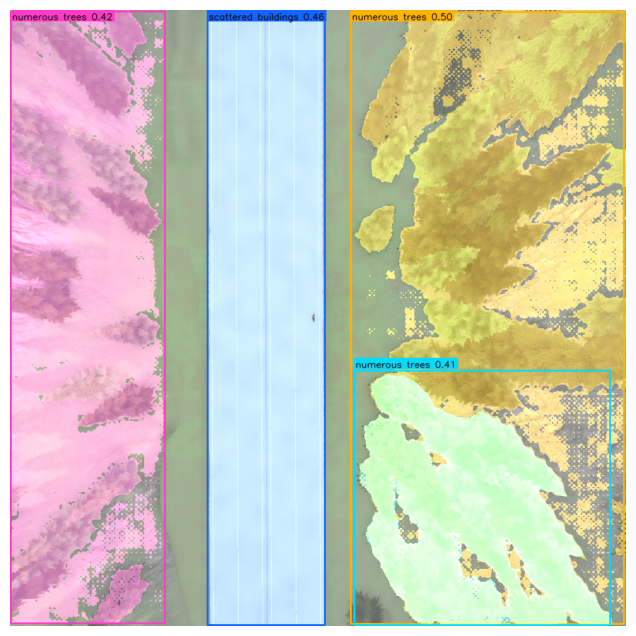

In [18]:
vis_img = visualise_segmentation(result, masks_dict)
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(vis_img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

In [19]:
result['detections']

[{'id': 0,
  'category': 'scattered buildings',
  'bbox_xyxy': [328.29, 0.73, 523.73, 1022.46],
  'confidence': 0.458,
  'is_goal': False,
  'source_prompt': 'scattered buildings',
  'prompt_index': 1,
  'grounding_phrase': 'scattered buildings',
  'mask_key': 'mask_0000',
  'dinov2_embedding': None},
 {'id': 1,
  'category': 'numerous trees',
  'bbox_xyxy': [566.85, 3.01, 1020.61, 1020.51],
  'confidence': 0.5026,
  'is_goal': False,
  'source_prompt': 'numerous trees',
  'prompt_index': 2,
  'grounding_phrase': 'numerous trees',
  'mask_key': 'mask_0001',
  'dinov2_embedding': None},
 {'id': 2,
  'category': 'numerous trees',
  'bbox_xyxy': [1.47, 2.33, 257.21, 1019.78],
  'confidence': 0.4246,
  'is_goal': False,
  'source_prompt': 'numerous trees',
  'prompt_index': 2,
  'grounding_phrase': 'numerous trees',
  'mask_key': 'mask_0002',
  'dinov2_embedding': None},
 {'id': 3,
  'category': 'numerous trees',
  'bbox_xyxy': [572.41, 599.85, 997.88, 1022.29],
  'confidence': 0.4053,
  '

In [20]:
feats = sam2_predictor._features['image_embed']
detections = result['detections']

feats.shape

torch.Size([1, 256, 64, 64])

In [21]:
from typing import NamedTuple
class ObsVertex(NamedTuple):
    """
    A single observation vertex for one detected object.

    Attributes
    ----------
    feature  : Tensor [D_g]  — projected SAM2 feature vector
    category : str           — normalised category name (e.g. "motorcycle")
    is_goal  : bool          — True if this object is the navigation goal
    """
    feature:  torch.Tensor
    category: str
    is_goal:  bool

In [22]:
import torch.nn.functional as F
def pool_mask(feat, mask_hw):
    C = feat.shape[1]
    Hf = feat.shape[2]
    Wf = feat.shape[3]
    device = feat.device

    mask_f32 = torch.from_numpy(mask_hw.astype(np.float32)).unsqueeze(0).unsqueeze(0)
    mask_resized = F.interpolate(
        mask_f32, size=(Hf, Wf), mode="nearest"
    ).squeeze(0).squeeze(0).bool().to(device) # [Hf, Wf]

    feat_sq = feat.squeeze(0)  #[1, C, Hf, Wf] → [C, Hf, Wf]

    n_true = mask_resized.sum().item()
    if n_true == 0:
        pooled = feat_sq.mean(dim=[1, 2])
    else:
        pooled = feat_sq[:, mask_resized].mean(dim=1)

    return pooled

sam2_feat_dim = 256
D_g = 256
projector_device = feats.device

obs_projector = nn.Sequential(
    nn.Linear(sam2_feat_dim, D_g),
    nn.LayerNorm(D_g),
).to(projector_device)

In [23]:
category_vecs: dict[str, list[torch.Tensor]] = {}
category_is_goal: dict[str, bool] = {}
category_order: list[str] = []   # insertion order (goal first)

for i, det in enumerate(detections):
    mask_hw = masks[i]
    raw_vec = pool_mask(feats, mask_hw)

    cat = det["category"]
    is_goal = bool(det["is_goal"])

    if cat not in category_vecs:
        category_vecs[cat] = []
        category_is_goal[cat] = is_goal
        if is_goal:
            category_order.insert(0, cat)
        else:
            category_order.append(cat)
    
    category_vecs[cat].append(raw_vec)

MAX_VERTICES = 5
vertices: list[ObsVertex] = []

for cat in category_order[:MAX_VERTICES]:
    stacked = torch.stack(category_vecs[cat], dim=0)  # [K, C]
    mean_vec = stacked.mean(dim=0)

    ok_vec = obs_projector(mean_vec.unsqueeze(0)).squeeze(0)  # [D_g]

    vertex = ObsVertex(
        feature=ok_vec,
        category=cat,
        is_goal=category_is_goal[cat],
    )
    vertices.append(vertex)


In [24]:
len(vertices)

2

In [25]:
vertices = []

for i, det in enumerate(detections):
    mask_hw = masks[i]

    raw_vec = pool_mask(feats, mask_hw)

    ok_vec = obs_projector(raw_vec.unsqueeze(0)).squeeze(0)

    vertex = ObsVertex(
        feature=ok_vec,
        category=det["category"],
        is_goal=bool(det["is_goal"]),
    )
    vertices.append(vertex)
    

In [26]:
def _build_obs_vertices(
    detections: list[dict],
    masks: np.ndarray,
    feats: torch.Tensor,
    aggregate_by_category: bool = True,
    max_vertices: int = 5,
) -> list[ObsVertex]:
    if len(detections) == 0 or masks.shape[0] == 0:
        return []

    first_param = next(obs_projector.parameters(), None)
    if first_param is not None and first_param.device != feats.device:
        obs_projector.to(feats.device)

    if aggregate_by_category:
        category_vecs: dict[str, list[torch.Tensor]] = {}
        category_is_goal: dict[str, bool] = {}
        category_order: list[str] = []

        for i, det in enumerate(detections):
            raw_vec = pool_mask(feats, masks[i])
            cat = det["category"]
            is_goal = bool(det["is_goal"])

            if cat not in category_vecs:
                category_vecs[cat] = []
                category_is_goal[cat] = is_goal
                if is_goal:
                    category_order.insert(0, cat)
                else:
                    category_order.append(cat)

            category_vecs[cat].append(raw_vec)

        vertices: list[ObsVertex] = []
        for cat in category_order[:max_vertices]:
            mean_vec = torch.stack(category_vecs[cat], dim=0).mean(dim=0)
            ok_vec = obs_projector(mean_vec.unsqueeze(0)).squeeze(0)
            vertices.append(
                ObsVertex(
                    feature=ok_vec,
                    category=cat,
                    is_goal=category_is_goal[cat],
                )
            )
        return vertices

    vertices: list[ObsVertex] = []
    for i, det in enumerate(detections):
        raw_vec = pool_mask(feats, masks[i])
        ok_vec = obs_projector(raw_vec.unsqueeze(0)).squeeze(0)
        vertices.append(
            ObsVertex(
                feature=ok_vec,
                category=det["category"],
                is_goal=bool(det["is_goal"]),
            )
        )
    return vertices


def build_vertices_for_timestep(
    episode_index: int,
    timestep: int,
    aggregate_observations: bool = True,
    max_observation_vertices: int = 5,
) -> dict:
    episode_timestep = load_episode_timestep(episode_index=episode_index, timestep=timestep)

    position_vertex = smolvlmencoder.forward(
        bev_image=episode_timestep["high_uav_image"],
        low_state=episode_timestep["low_uav_pose"],
        high_state=episode_timestep["high_uav_pose"],
        lang_description=episode_timestep["lang_description"],
    )

    goal, contextual, desc = parse_instruction([episode_timestep["lang_description"]])
    goal_object = _normalise_category(goal)
    contextual_nouns = [_normalise_category(noun) for noun in contextual]
    prompt_list = build_prompt_list(goal_object, contextual_nouns)

    image_source, image_tensor = load_image(str(episode_timestep["bev_frame_path"]))
    h, w = image_source.shape[:2]

    candidates = _detect_per_prompt(
        image_tensor=image_tensor,
        image_width=w,
        image_height=h,
        prompt_list=prompt_list,
        goal_object=goal_object,
        grounding_model=grounding_model,
        device=device,
        box_threshold=BOX_THRESHOLD,
        text_threshold=TEXT_THRESHOLD,
    )

    boxes_px = np.asarray([cand["bbox_xyxy"] for cand in candidates], dtype=np.float32)
    nms_scores = np.asarray([cand["nms_score"] for cand in candidates], dtype=np.float32)
    keep = _apply_nms(boxes_px, nms_scores, NMS_IOU_THRESH)
    kept_candidates = [candidates[i] for i in keep.tolist()]
    kept_candidates.sort(key=lambda c: (-int(c["is_goal"]), c["prompt_index"], -c["confidence"]))
    boxes_px = np.asarray([cand["bbox_xyxy"] for cand in kept_candidates], dtype=np.float32)

    sam2_predictor.set_image(image_source)

    if len(boxes_px) == 0:
        masks = np.zeros((0, h, w), dtype=bool)
    else:
        masks, scores, _ = sam2_predictor.predict(
            point_coords=None,
            point_labels=None,
            box=boxes_px,
            multimask_output=False,
        )
        if masks.ndim == 4:
            masks = masks[:, 0]

    goal_detected = False
    detections = []

    for idx, (candidate, bbox) in enumerate(zip(kept_candidates, boxes_px.tolist())):
        is_goal = bool(goal_object and candidate["category"] == goal_object)
        if is_goal:
            goal_detected = True

        detections.append({
            "id": idx,
            "category": candidate["category"],
            "bbox_xyxy": [round(v, 2) for v in bbox],
            "confidence": round(float(candidate["confidence"]), 4),
            "is_goal": is_goal,
            "source_prompt": candidate["prompt"],
            "prompt_index": candidate["prompt_index"],
            "grounding_phrase": candidate["raw_grounding_label"],
            "mask_key": f"mask_{idx:04d}",
            "dinov2_embedding": None,
        })

    result = {
        "episode_index": episode_index,
        "episode_name": episode_timestep["sample"].name,
        "timestep": episode_timestep["timestep"],
        "image_path": str(episode_timestep["bev_frame_path"]),
        "image_width": w,
        "image_height": h,
        "goal_category": goal_object,
        "goal_detected": goal_detected,
        "prompt_list": prompt_list,
        "num_detections": len(detections),
        "detections": detections,
        "description_text": desc,
        "contextual_categories": contextual,
    }
    result["_masks_array"] = masks

    feats = sam2_predictor._features["image_embed"]
    observation_vertices = _build_obs_vertices(
        detections=detections,
        masks=masks,
        feats=feats,
        aggregate_by_category=aggregate_observations,
        max_vertices=max_observation_vertices,
    )

    masks_dict = {d["mask_key"]: masks[i] for i, d in enumerate(detections)}

    return {
        "episode_timestep": episode_timestep,
        "position_vertex": position_vertex,
        "observation_vertices": observation_vertices,
        "segmentation_result": result,
        "masks_dict": masks_dict,
    }


def build_episode_vertices(
    episode_index: int,
    timesteps=None,
    aggregate_observations: bool = True,
    max_observation_vertices: int = 5,
) -> dict[int, dict]:
    if timesteps is None:
        max_valid_timestep = load_episode_timestep(episode_index=episode_index, timestep=0)["max_valid_timestep"]
        timesteps = range(max_valid_timestep + 1)

    return {
        t: build_vertices_for_timestep(
            episode_index=episode_index,
            timestep=t,
            aggregate_observations=aggregate_observations,
            max_observation_vertices=max_observation_vertices,
        )
        for t in timesteps
    }


def _ensure_2d_position_tensor(position_vertex: torch.Tensor) -> torch.Tensor:
    if position_vertex.dim() == 3:
        if position_vertex.shape[0] != 1:
            raise ValueError(
                f"Expected batched position vertex with batch size 1, got {tuple(position_vertex.shape)}"
            )
        return position_vertex.squeeze(0)
    if position_vertex.dim() == 2:
        return position_vertex
    if position_vertex.dim() == 1:
        return position_vertex.unsqueeze(0)
    raise ValueError(f"Unsupported position vertex shape: {tuple(position_vertex.shape)}")


def _ensure_1d_obs_feature(feature: torch.Tensor) -> torch.Tensor:
    if feature.dim() == 2:
        if feature.shape[0] != 1:
            raise ValueError(f"Expected observation feature shape [D] or [1, D], got {tuple(feature.shape)}")
        return feature.squeeze(0)
    if feature.dim() == 1:
        return feature
    raise ValueError(f"Unsupported observation feature shape: {tuple(feature.shape)}")


def _pad_and_stack_2d(tensors: list[torch.Tensor], pad_value: float = 0.0) -> torch.Tensor:
    if not tensors:
        raise ValueError("Cannot stack an empty list of tensors.")

    feature_dim = tensors[0].shape[-1]
    max_len = max(t.shape[0] for t in tensors)
    device = tensors[0].device
    dtype = tensors[0].dtype

    stacked = torch.full(
        (len(tensors), max_len, feature_dim),
        pad_value,
        device=device,
        dtype=dtype,
    )

    for i, tensor in enumerate(tensors):
        if tensor.shape[-1] != feature_dim:
            raise ValueError(
                f"All tensors must share the same feature dim. Expected {feature_dim}, got {tensor.shape[-1]}"
            )
        if tensor.shape[0] > 0:
            stacked[i, :tensor.shape[0]] = tensor

    return stacked


def stack_episode_vertices(
    episode_vertices: dict[int, dict],
    pad_value: float = 0.0,
) -> tuple[torch.Tensor, torch.Tensor]:
    """
    Stack episode vertices in sorted timestep order.

    Returns
    -------
    position_vertices : Tensor [T, max_position_tokens, position_dim]
        Zero-padded along the token axis when sequence lengths differ.
    observation_vertices : Tensor [T, max_num_observations, obs_dim]
        Zero-padded along the observation axis when the number of detected
        observation vertices differs across timesteps.
    """
    if not episode_vertices:
        raise ValueError("episode_vertices is empty.")

    ordered_timesteps = sorted(episode_vertices)

    position_tensors = [
        _ensure_2d_position_tensor(episode_vertices[t]["position_vertex"])
        for t in ordered_timesteps
    ]
    position_vertices = _pad_and_stack_2d(position_tensors, pad_value=pad_value)

    obs_feature_dim = obs_projector[0].out_features
    observation_tensors: list[torch.Tensor] = []

    for t in ordered_timesteps:
        obs_vertices_t = episode_vertices[t]["observation_vertices"]

        if obs_vertices_t:
            observation_tensors.append(
                torch.stack([
                    _ensure_1d_obs_feature(obs.feature)
                    for obs in obs_vertices_t
                ], dim=0)
            )
        else:
            observation_tensors.append(
                torch.empty(
                    (0, obs_feature_dim),
                    device=position_vertices.device,
                    dtype=position_vertices.dtype,
                )
            )

    observation_vertices = _pad_and_stack_2d(observation_tensors, pad_value=pad_value)
    return position_vertices, observation_vertices


# Example usage:
# timestep_vertices = build_vertices_for_timestep(episode_index=0, timestep=7)
# episode_vertices = build_episode_vertices(episode_index=0, timesteps=[0, 7, 14])
# position_vertices, observation_vertices = stack_episode_vertices(episode_vertices)

In [27]:
episode_vertices = build_episode_vertices(episode_index=0, timesteps=[0, 1, 2, 3, 4])
position_vertices, observation_vertices = stack_episode_vertices(episode_vertices)

In [28]:
position_vertices.shape, observation_vertices.shape

(torch.Size([5, 191, 2048]), torch.Size([5, 3, 256]))

In [29]:
from high_uav.position_vertex_builder import PositionVertexBuilder

place_node_builder = PositionVertexBuilder(
    smolvlm2_hidden_dim=2048,
    D_g=256,
    perceiver_M=64,
    perceiver_D_latent=256,
    perceiver_depth=2,
    perceiver_n_heads=8,
).to(position_vertices.device)

In [30]:
# position_vertices: [T, 191, 2048]  (already on CUDA from SmolVLM2Encoder)
# PerceiverIO compresses each timestep [191, 2048] → [D_g] independently
place_nodes = place_node_builder(position_vertices)   # [T, D_g]

print("position_vertices :", position_vertices.shape)
print("place_nodes        :", place_nodes.shape)       # expected [5, 256]

position_vertices : torch.Size([5, 191, 2048])
place_nodes        : torch.Size([5, 256])


In [31]:
place_nodes

tensor([[-0.0220, -0.0323, -0.0358,  ...,  0.0680, -0.0552, -0.0972],
        [-0.0248, -0.0323, -0.0367,  ...,  0.0667, -0.0563, -0.0994],
        [-0.0197, -0.0325, -0.0364,  ...,  0.0673, -0.0548, -0.0969],
        [-0.0219, -0.0318, -0.0354,  ...,  0.0671, -0.0547, -0.0967],
        [-0.0189, -0.0310, -0.0366,  ...,  0.0688, -0.0590, -0.0939]],
       device='cuda:0', grad_fn=<SqueezeBackward1>)

In [32]:
from high_uav.graph_encoder import GraphEncoder

graph_encoder = GraphEncoder(
    D_g=256,
    num_layers=3,
    heads=4,
).to(place_nodes.device)

In [33]:
# place_nodes          : [T, D_g]        = [5, 256]  — from PositionVertexBuilder
# observation_vertices : [T, K_max, D_g] = [5, 3, 256] — zero-padded obs features
z_graph = graph_encoder(place_nodes, observation_vertices)   # [T, D_g]

print("place_nodes          :", place_nodes.shape)
print("observation_vertices :", observation_vertices.shape)
print("z_graph              :", z_graph.shape)    # expected [5, 256]

place_nodes          : torch.Size([5, 256])
observation_vertices : torch.Size([5, 3, 256])
z_graph              : torch.Size([5, 256])


In [34]:
z_graph

tensor([[ 0.2777, -0.1559, -0.5343,  ...,  0.3414, -0.8314, -1.1330],
        [ 0.1914, -0.2521, -0.5227,  ...,  0.3617, -0.9146, -1.1658],
        [ 0.3139, -0.1884, -0.4526,  ...,  0.3445, -0.9065, -1.1576],
        [ 0.0718, -0.2716, -0.4783,  ...,  0.4257, -0.9254, -1.1251],
        [ 0.1853, -0.4207, -0.4358,  ...,  0.7463, -0.7748, -1.0976]],
       device='cuda:0', grad_fn=<NativeLayerNormBackward0>)

In [35]:
from high_uav.flow_matching import FlowMatchingNetwork
import torch.nn.functional as F

flow_net = FlowMatchingNetwork(cfg).to(z_graph.device)

In [36]:
# # Load the actual low UAV trajectory so x_clean uses real episode data
# import json as _json
# with open(sample / "low_uav_traj.json") as f:
#     _low_traj = torch.tensor(_json.load(f)["normalized_state"], dtype=torch.float32)

# # Anchor: last timestep of the graph window
# anchor_t = max(episode_vertices.keys())                   # t = 4
# low_state_anchor = episode_vertices[anchor_t]["episode_timestep"]["low_uav_pose"]  # [4]

# H = cfg.action_horizon                                     # 8
# low_traj = _low_traj[anchor_t : anchor_t + H]             # [H, 4] — clean trajectory

# # Flow-matching interpolation — convention: τ=0 → noise, τ=1 → clean data
# #   x_τ = (1 − τ)·noise + τ·clean
# #   v_target = clean − noise
# x_clean  = low_traj.to(z_graph.device)                    # clean data at τ=1
# noise    = torch.randn_like(x_clean)                       # pure noise at τ=0
# tau      = torch.rand(1, device=z_graph.device)            # scalar in [0, 1]
# x_tau    = (1 - tau) * noise + tau * x_clean               # interpolated noisy trajectory
# v_target = x_clean - noise                                 # target velocity

# # retain_grad() on non-leaf tensors so .grad is populated after backward
# z_graph.retain_grad()

# v_pred = flow_net(z_graph, low_state_anchor.to(z_graph.device), x_tau, tau)
# L_flow = F.mse_loss(v_pred, v_target)

# print("z_graph      :", z_graph.shape)           # [5, 256]
# print("low_state    :", low_state_anchor.shape)   # [4]
# print("x_tau        :", x_tau.shape)              # [8, 4]
# print("v_pred       :", v_pred.shape)             # [8, 4]
# print("L_flow       :", L_flow.item())

# # Backward — kept in the same cell as the forward pass so re-running always
# # rebuilds a fresh graph before calling .backward().
# if z_graph.grad is not None:
#     z_graph.grad.zero_()

# L_flow.backward()

# print("grad through z_graph            :", z_graph.grad is not None)

# def _has_grad(module):
#     return any(p.grad is not None for p in module.parameters() if p.requires_grad)

# print("grad → FlowMatchingNetwork      :", _has_grad(flow_net))
# print("grad → GraphEncoder             :", _has_grad(graph_encoder))
# print("grad → PositionVertexBuilder    :", _has_grad(place_node_builder))
# print("grad → obs_projector            :", _has_grad(obs_projector))

In [37]:
from diffusers.models.embeddings import SinusoidalPositionalEmbedding, TimestepEmbedding, Timesteps
from diffusers.models.attention import Attention, FeedForward

class AdaLayerNorm(nn.Module):
    def __init__(
        self,
        embedding_dim: int,
        norm_elementwise_affine: bool = False,
        norm_eps: float = 1e-5,
        chunk_dim: int = 0,
    ):
        super().__init__()
        self.chunk_dim = chunk_dim
        output_dim = embedding_dim * 2
        self.silu = nn.SiLU()
        self.linear = nn.Linear(embedding_dim, output_dim)
        self.norm = nn.LayerNorm(output_dim // 2, norm_eps, norm_elementwise_affine)

    def forward(
        self,
        x: torch.Tensor,
        temb: Optional[torch.Tensor] = None,
    ) -> torch.Tensor:
        temb = self.linear(self.silu(temb))
        scale, shift = temb.chunk(2, dim=1)
        x = self.norm(x) * (1 + scale[:, None]) + shift[:, None]
        return x


def _is_spark_sm121() -> bool:
    if not torch.cuda.is_available():
        return False

    major, minor = torch.cuda.get_device_capability()
    return (major, minor) == (12, 1)


def _should_force_math_sdpa() -> bool:
    override = os.environ.get("GR00T_DIT_SDPA_MODE")
    if override == "math":
        return True
    if override == "default":
        return False

    return _is_spark_sm121()


def _sdpa_context():
    # Spark (sm121) currently hits noisy/broken PyTorch mem-efficient SDPA kernel dispatch.
    # Force the safe math backend there; on every other platform this returns a no-op context.
    if not _should_force_math_sdpa():
        return nullcontext()

    return torch.backends.cuda.sdp_kernel(
        enable_flash=False,
        enable_math=True,
        enable_mem_efficient=False,
        enable_cudnn=False,
    )

In [38]:

class BasicTransformerBlock(nn.Module):
    def __init__(
        self,
        dim: int,
        num_attention_heads: int,
        attention_head_dim: int,
        dropout=0.0,
        cross_attention_dim: Optional[int] = None,
        activation_fn: str = "geglu",
        attention_bias: bool = False,
        upcast_attention: bool = False,
        norm_elementwise_affine: bool = True,
        norm_type: str = "layer_norm",  # 'layer_norm', 'ada_norm', 'ada_norm_zero', 'ada_norm_single', 'ada_norm_continuous', 'layer_norm_i2vgen'
        norm_eps: float = 1e-5,
        final_dropout: bool = False,
        attention_type: str = "default",
        positional_embeddings: Optional[str] = None,
        num_positional_embeddings: Optional[int] = None,
        ff_inner_dim: Optional[int] = None,
        ff_bias: bool = True,
        attention_out_bias: bool = True,
    ):
        super().__init__()
        self.dim = dim
        self.num_attention_heads = num_attention_heads
        self.attention_head_dim = attention_head_dim
        self.dropout = dropout
        self.cross_attention_dim = cross_attention_dim
        self.activation_fn = activation_fn
        self.attention_bias = attention_bias
        self.norm_elementwise_affine = norm_elementwise_affine
        self.positional_embeddings = positional_embeddings
        self.num_positional_embeddings = num_positional_embeddings
        self.norm_type = norm_type

        if positional_embeddings and (num_positional_embeddings is None):
            raise ValueError(
                "If `positional_embedding` type is defined, `num_positition_embeddings` must also be defined."
            )

        if positional_embeddings == "sinusoidal":
            self.pos_embed = SinusoidalPositionalEmbedding(
                dim, max_seq_length=num_positional_embeddings
            )
        else:
            self.pos_embed = None

        # Define 3 blocks. Each block has its own normalization layer.
        # 1. Self-Attn
        if norm_type == "ada_norm":
            self.norm1 = AdaLayerNorm(dim)
        else:
            self.norm1 = nn.LayerNorm(dim, elementwise_affine=norm_elementwise_affine, eps=norm_eps)

        self.attn1 = Attention(
            query_dim=dim,
            heads=num_attention_heads,
            dim_head=attention_head_dim,
            dropout=dropout,
            bias=attention_bias,
            cross_attention_dim=cross_attention_dim,
            upcast_attention=upcast_attention,
            out_bias=attention_out_bias,
        )

        # 3. Feed-forward
        self.norm3 = nn.LayerNorm(dim, norm_eps, norm_elementwise_affine)
        self.ff = FeedForward(
            dim,
            dropout=dropout,
            activation_fn=activation_fn,
            final_dropout=final_dropout,
            inner_dim=ff_inner_dim,
            bias=ff_bias,
        )
        if final_dropout:
            self.final_dropout = nn.Dropout(dropout)
        else:
            self.final_dropout = None

    def forward(
        self,
        hidden_states: torch.Tensor,
        attention_mask: Optional[torch.Tensor] = None,
        encoder_hidden_states: Optional[torch.Tensor] = None,
        encoder_attention_mask: Optional[torch.Tensor] = None,
        temb: Optional[torch.LongTensor] = None,
    ) -> torch.Tensor:
        # 0. Self-Attention
        if self.norm_type == "ada_norm":
            norm_hidden_states = self.norm1(hidden_states, temb)
        else:
            norm_hidden_states = self.norm1(hidden_states)

        if self.pos_embed is not None:
            norm_hidden_states = self.pos_embed(norm_hidden_states)

        with _sdpa_context():
            attn_output = self.attn1(
                norm_hidden_states,
                encoder_hidden_states=encoder_hidden_states,
                attention_mask=(
                    encoder_attention_mask if encoder_hidden_states is not None else attention_mask
                ),
            )
        if self.final_dropout:
            attn_output = self.final_dropout(attn_output)

        hidden_states = attn_output + hidden_states
        if hidden_states.ndim == 4:
            hidden_states = hidden_states.squeeze(1)

        # 4. Feed-forward
        norm_hidden_states = self.norm3(hidden_states)
        ff_output = self.ff(norm_hidden_states)

        hidden_states = ff_output + hidden_states
        if hidden_states.ndim == 4:
            hidden_states = hidden_states.squeeze(1)
        return hidden_states

In [39]:
cross_attention_dim = 2048
interleave_self_attention = True
num_attention_heads = 32
attention_head_dim = 48
inner_dim = num_attention_heads * attention_head_dim
dropout = 0.2
activation_fn='geglu'

all_blocks = []
for i in range(2):
    use_self_attn = i % 2 == 1 and interleave_self_attention
    curr_cross_attention_dim = cross_attention_dim if not use_self_attn else None

    all_blocks += [
        BasicTransformerBlock(
            inner_dim,
            num_attention_heads,
            attention_head_dim,
            dropout=dropout,
            activation_fn=activation_fn,
            attention_bias=False,
            upcast_attention=False,
            norm_type='ada_norm',
            norm_elementwise_affine=True,
            norm_eps=1e-15,
            positional_embeddings=None,
            num_positional_embeddings=None,
            final_dropout=True,
            cross_attention_dim=curr_cross_attention_dim,
        )
    ]
    transformerblock = nn.ModuleList(all_blocks)


In [40]:
len(transformerblock)

2

In [41]:
transformerblock

ModuleList(
  (0): BasicTransformerBlock(
    (norm1): AdaLayerNorm(
      (silu): SiLU()
      (linear): Linear(in_features=1536, out_features=3072, bias=True)
      (norm): LayerNorm((1536,), eps=1e-05, elementwise_affine=False)
    )
    (attn1): Attention(
      (to_q): Linear(in_features=1536, out_features=1536, bias=False)
      (to_k): Linear(in_features=2048, out_features=1536, bias=False)
      (to_v): Linear(in_features=2048, out_features=1536, bias=False)
      (to_out): ModuleList(
        (0): Linear(in_features=1536, out_features=1536, bias=True)
        (1): Dropout(p=0.2, inplace=False)
      )
    )
    (norm3): LayerNorm((1536,), eps=1e-15, elementwise_affine=True)
    (ff): FeedForward(
      (net): ModuleList(
        (0): GEGLU(
          (proj): Linear(in_features=1536, out_features=12288, bias=True)
        )
        (1): Dropout(p=0.2, inplace=False)
        (2): Linear(in_features=6144, out_features=1536, bias=True)
        (3): Dropout(p=0.2, inplace=False)
  

In [42]:
from flow_matching import FlowDenoiserBlock

In [43]:
blocks = nn.ModuleList([
    FlowDenoiserBlock(
        dim=256,
        num_attention_heads=4,
        attention_head_dim=256 // 4,
        ffn_mult=4,
        activation_fn="gelu-approximate",
        attention_bias=True,
        cross_attention_dim=256
    )
    for _ in range(2)
])

In [44]:
blocks

ModuleList(
  (0-1): 2 x FlowDenoiserBlock(
    (norm1): AdaLayerNorm(
      (silu): SiLU()
      (linear): Linear(in_features=256, out_features=512, bias=True)
      (norm): LayerNorm((256,), eps=1e-05, elementwise_affine=False)
    )
    (attn1): Attention(
      (to_q): Linear(in_features=256, out_features=256, bias=True)
      (to_k): Linear(in_features=256, out_features=256, bias=True)
      (to_v): Linear(in_features=256, out_features=256, bias=True)
      (to_out): ModuleList(
        (0): Linear(in_features=256, out_features=256, bias=True)
        (1): Dropout(p=0.0, inplace=False)
      )
    )
    (norm2): AdaLayerNorm(
      (silu): SiLU()
      (linear): Linear(in_features=256, out_features=512, bias=True)
      (norm): LayerNorm((256,), eps=1e-05, elementwise_affine=False)
    )
    (attn2): Attention(
      (to_q): Linear(in_features=256, out_features=256, bias=True)
      (to_k): Linear(in_features=256, out_features=256, bias=True)
      (to_v): Linear(in_features=256, 

In [45]:
transformerblock

ModuleList(
  (0): BasicTransformerBlock(
    (norm1): AdaLayerNorm(
      (silu): SiLU()
      (linear): Linear(in_features=1536, out_features=3072, bias=True)
      (norm): LayerNorm((1536,), eps=1e-05, elementwise_affine=False)
    )
    (attn1): Attention(
      (to_q): Linear(in_features=1536, out_features=1536, bias=False)
      (to_k): Linear(in_features=2048, out_features=1536, bias=False)
      (to_v): Linear(in_features=2048, out_features=1536, bias=False)
      (to_out): ModuleList(
        (0): Linear(in_features=1536, out_features=1536, bias=True)
        (1): Dropout(p=0.2, inplace=False)
      )
    )
    (norm3): LayerNorm((1536,), eps=1e-15, elementwise_affine=True)
    (ff): FeedForward(
      (net): ModuleList(
        (0): GEGLU(
          (proj): Linear(in_features=1536, out_features=12288, bias=True)
        )
        (1): Dropout(p=0.2, inplace=False)
        (2): Linear(in_features=6144, out_features=1536, bias=True)
        (3): Dropout(p=0.2, inplace=False)
  

In [46]:
from diffusers.models.attention import Attention, FeedForward

In [47]:
from high_uav.dataset import AeroduoDataset, collate_fn

In [48]:
dataset = AeroduoDataset(
    dataset_root="/storage/project/r-cj124-0/sibidapo3/8750/aeroduo_ws/aeroduo/data/Hal-13k",
    window_T=5,
    action_horizon=16,
)

In [63]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(
        dataset,
        batch_size=1,
        shuffle=True,
        num_workers=0,          # SAM2 / SmolVLM2 are not picklable
        collate_fn=collate_fn,
    )

In [64]:
from typing import Dict, Optional
_POLICY_KEYS = frozenset({
    "bev_images",
    "high_uav_poses",
    "low_uav_poses_window",
    "low_uav_pose_current",
    "low_uav_traj_target",
    "instruction",
})

for _step, batch in enumerate(train_dataloader):
    policy_inputs: Dict = {k: v for k, v in batch.items() if k in _POLICY_KEYS}
    if _step > 1:
        break
    

In [65]:
bev_images = batch['bev_images']
high_uav_poses = batch['high_uav_poses']
low_uav_poses_window = batch['low_uav_poses_window']
low_uav_pose_current = batch['low_uav_pose_current']
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
low_uav_traj_target = batch['low_uav_traj_target']
instruction = batch['instruction']

## Inside Encode Graph

In [ ]:
from typing import Dict, List, Optional, Tuple
from bev_encoder import BEVEncoder
from smolvlm2_encoder import SmolVLM2Encoder

cfg = AeroduoConfig()

sam2_predictor, grounding_model, _ = load_models(device=device)
bev_encoder = BEVEncoder(sam2_predictor, grounding_model)
vlm_encoder = SmolVLM2Encoder(cfg)

B = len(instruction)
T = len(bev_images[0])
dtype = torch.float32

all_image_embeds: List[torch.Tensor]     = []   # B × Tensor[T,256,64,64]
all_masks:        List[List]             = []   # B × T × ndarray[N,H,W]
all_detections:   List[List]             = []   # B × T × List[dict]
all_hidden:       List[torch.Tensor]     = []   # B × Tensor[T, S, 2048]

for b in range(B):
    # BEVEncoder: one Hiera forward for all T frames in this episode
    img_embs_b, masks_b, dets_b = bev_encoder(
        bev_images[b], instruction[b], device
    )   # img_embs_b: [T, 256, 64, 64]
    all_image_embeds.append(img_embs_b)
    all_masks.append(masks_b)
    all_detections.append(dets_b)

    # SmolVLM2: per-frame within this episode
    hs_b: List[torch.Tensor] = []
    for t in range(T):
        with torch.autocast(device_type='cuda', dtype=torch.bfloat16):
            h = vlm_encoder(
                bev_image=bev_images[b][t],
                lang_description=instruction[b],
                low_state=low_uav_poses_window[b, t:t + 1].to(device),
                high_state=high_uav_poses[b, t:t + 1].to(device),
                device=device,
            )       # [1, S, 2048]
        hs_b.append(h.squeeze(0))      # [S, 2048]
    all_hidden.append(torch.stack(hs_b))  # [T, S, 2048]



Loading checkpoint shards: 100%|██████████| 2/2 [00:23<00:00, 11.56s/it]


In [67]:
position_vertices = torch.stack(all_hidden).to(dtype=dtype)

In [71]:
position_vertices.shape

torch.Size([1, 5, 205, 2048])